# ファクター検証　（reprisk）

`input/msci_india_imi/alpha/reprisk/repr_current_rri`（RepRisk Index, RRI）の検証

## 2018 年以降の消失の検証

### 目的

`04` `05` で、「RRI 25 以上」の劣後は 2008〜2017 年に集中し、2018 年以降は観測されないことが分かった。
この Notebook では消失の原因を切り分ける。

1. **テールの定義**: 水準（25 以上）ではなくクロスセクションの順位（上位 x%）でテールを定義した場合に、
   2018 年以降も効果が残るか。RepRisk のカバレッジ拡張で 25 以上の銘柄数が 9 → 60 超へ増えており、
   「25 以上」の意味が変わった可能性を検証する
2. **構成の変化**: 25 以上の業種・サイズ構成が 2018 年前後でどう変わったか。業種で説明できるなら、
   業種中立で見た効果が残るかを確認する
3. **IC の期間別推移**: Spearman IC、25 以上ダミー、上位 x% ダミーの IC を期間別・ローリングで見る

### 定義

- セグメントは S3〜S5（サイズ 5 分位の中型・大型）、ウェイトは等ウェイト、参照は同セグメントのスコアあり銘柄の等ウェイト
- 上位 x% テール: 各月、S3〜S5 のスコアあり銘柄の中で RRI の順位パーセンタイルが $1 - x$ を超える銘柄
- 業種は `alpha/attributes/gics`（8 桁 GICS）の先頭 2 桁（セクター）
- 期間区分: 前期 = 2008-01〜2017-12、後期 = 2018-01〜2026-06
- IC はスコアの符号を反転（$-\text{RRI}$）して「正 = RRI が低いほど翌月リターンが高い」に揃える

In [1]:
import matplotlib.pyplot as plt
import japanize_matplotlib  # noqa: F401  日本語ラベル用
import numpy as np
import pandas as pd

from alphaeval import InputStore, forward_returns, ic_summary, information_coefficient, performance_summary, portfolio_returns, turnover, weight_portfolio

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 40)

# ---- パラメータ
INPUT_ROOT = "../../input/msci_india_imi"
SCORE = "reprisk/repr_current_rri"
BENCHMARK = "msci_india"
RISK_MODEL, RETURN_COL = "GEMLT", "rtn"
START, END = 200801, 202606
N_SIZE_BINS = 5
SIZE_BINS_USED = [3, 4, 5]
TAIL_LEVEL = 24.5
TOP_PCTS = [0.05, 0.10, 0.15]
SPLIT = "2018-01-01"
PERIODS = {"全期間": (None, None), "前期 〜2017": (None, "2017-12-31"), "後期 2018〜": (SPLIT, None)}
SECTOR_NAMES = {10: "エネルギー", 15: "素材", 20: "資本財", 25: "一般消費財", 30: "生活必需品", 35: "ヘルスケア", 40: "金融", 45: "情報技術", 50: "通信", 55: "公益", 60: "不動産"}

store = InputStore(INPUT_ROOT)

### 1. データ読み込み

In [2]:
univ = store.universe(START, END)
bm = store.benchmark(BENCHMARK, START, END)
score = store.alpha(SCORE, START, END)
rtn = store.returns(RISK_MODEL, RETURN_COL, START, 202607)
gics = store.alpha("attributes/gics", START, END).reindex(columns=univ.columns)

score_u = score.where(univ.notna()).reindex(columns=univ.columns)
log_size = np.log(univ.where(univ > 0))
size_bin = np.ceil(log_size.rank(axis=1, pct=True) * N_SIZE_BINS).clip(1, N_SIZE_BINS)
sector = (gics // 1_000_000).where(univ.notna())

seg = size_bin.isin(SIZE_BINS_USED)
s_seg = score_u.where(seg)
scored = s_seg.notna()
ref_ret = portfolio_returns(weight_portfolio(scored), rtn)     # S3–S5 スコアあり銘柄の等ウェイト
bm_ret = portfolio_returns(bm, rtn)
print(f"期間: {univ.index.min().date()} 〜 {univ.index.max().date()} ({len(univ)} か月)")
print(f"S3–S5 スコアあり 平均 {scored.sum(axis=1).mean():.0f} 銘柄, GICS 欠損率 {(scored & sector.isna()).sum().sum() / scored.sum().sum():.2%}")

期間: 2008-01-31 〜 2026-06-30 (222 か月)
S3–S5 スコアあり 平均 178 銘柄, GICS 欠損率 0.00%


In [3]:
def group_return(member: pd.DataFrame) -> pd.Series:
    return portfolio_returns(weight_portfolio(member.fillna(False)), rtn)


def period_slice(s: pd.Series, period: tuple) -> pd.Series:
    lo, hi = period
    return s.loc[lo:hi]


def spread_table(spreads: dict[str, pd.Series], counts: dict[str, pd.Series] | None = None) -> pd.DataFrame:
    """スプレッド系列を期間別に集計（年率、R/R、勝率、平均銘柄数）。"""
    rows = {}
    for name, z in spreads.items():
        for pname, per in PERIODS.items():
            zz = period_slice(z.dropna(), per)
            row = {"年率": zz.mean() * 12, "年率リスク": zz.std() * np.sqrt(12), "R/R": zz.mean() / zz.std() * np.sqrt(12), "勝率": (zz > 0).mean(), "月数": len(zz)}
            if counts is not None and name in counts:
                row["平均銘柄数"] = period_slice(counts[name], per).mean()
            rows[(name, pname)] = row
    df = pd.DataFrame(rows).T
    df.index.names = ["定義", "期間"]
    return df

### 2. テールの定義: 水準（25 以上）vs 順位（上位 x%）

各定義について「参照 − テール」（テールを避けることの効果）のスプレッドを期間別に見る。

In [4]:
pct = s_seg.rank(axis=1, pct=True)     # 昇順: RRI が高いほど 1 に近い
tails = {"水準 25以上": s_seg >= TAIL_LEVEL}
for x in TOP_PCTS:
    tails[f"上位 {int(x * 100)}%"] = pct > 1 - x
# 上位 x% は非ゼロに限る（ゼロが同順位で上位に入ることは無いが念のため）
tails = {k: (m & (s_seg > 0)) for k, m in tails.items()}

tail_ret = {k: group_return(m) for k, m in tails.items()}
tail_n = {k: m.sum(axis=1) for k, m in tails.items()}
spreads = {k: ref_ret - r for k, r in tail_ret.items()}
display(spread_table(spreads, tail_n).round(3))

年率  年率リスク    R/R     勝率     月数   平均銘柄数
定義      期間                                                 
水準 25以上 全期間       0.062  0.109  0.571  0.554  222.0  17.468
        前期 〜2017  0.139  0.118  1.178  0.630  119.0  11.475
        後期 2018〜 -0.027  0.092 -0.289  0.466  103.0  24.520
上位 5%   全期間       0.034  0.135  0.252  0.523  222.0   9.306
        前期 〜2017  0.087  0.127  0.681  0.580  119.0   7.975
        後期 2018〜 -0.027  0.142 -0.190  0.456  103.0  10.873
上位 10%  全期間       0.026  0.101  0.257  0.541  222.0  17.959
        前期 〜2017  0.052  0.105  0.498  0.597  119.0  15.275
        後期 2018〜 -0.005  0.096 -0.048  0.476  103.0  21.118
上位 15%  全期間       0.013  0.079  0.160  0.532  222.0  27.266
        前期 〜2017  0.038  0.084  0.453  0.580  119.0  23.383
        後期 2018〜 -0.016  0.073 -0.227  0.476  103.0  31.833

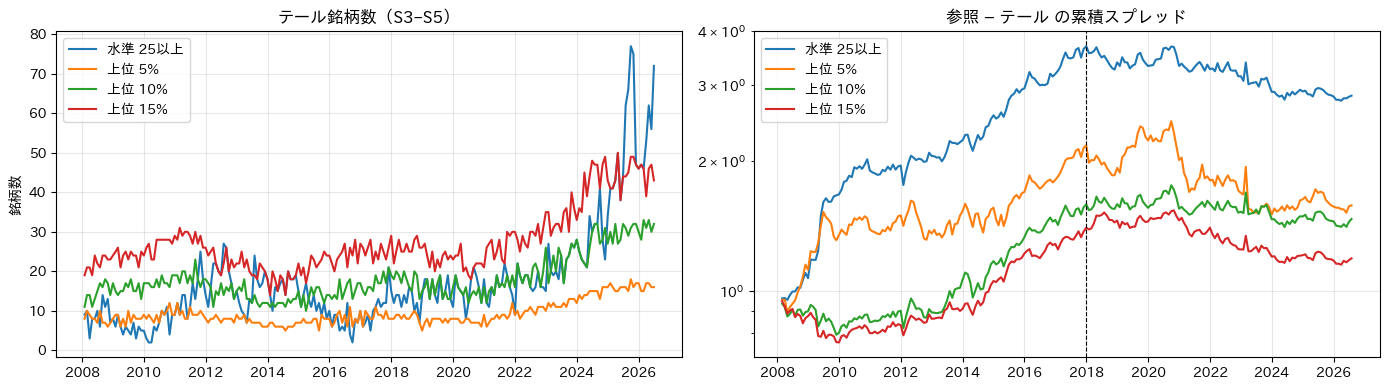

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for k, n in tail_n.items():
    axes[0].plot(n.index, n, label=k)
axes[0].set_title("テール銘柄数（S3–S5）")
axes[0].set_ylabel("銘柄数")
axes[0].legend()
axes[0].grid(alpha=0.3)
for k, z in spreads.items():
    rel = (1 + z.fillna(0)).cumprod()
    axes[1].plot(rel.index, rel, label=k)
axes[1].axvline(pd.Timestamp(SPLIT), color="k", linestyle="--", linewidth=0.8)
axes[1].set_yscale("log")
axes[1].set_title("参照 − テール の累積スプレッド")
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
ys = pd.DataFrame({k: z.groupby(z.index.year).apply(lambda x: (1 + x).prod() - 1) for k, z in spreads.items()})
display(ys.round(3))

,水準 25以上,上位 5%,上位 10%,上位 15%
2008,0.073,0.122,-0.101,-0.123
2009,0.563,0.203,-0.109,-0.131
2010,0.135,0.030,0.059,0.051
2011,0.027,0.078,0.063,0.044
2012,0.052,-0.092,-0.009,0.034
2013,0.088,0.127,0.191,0.055
2014,0.142,0.018,0.104,0.160
2015,0.154,0.087,0.136,0.158
2016,0.080,0.068,0.097,0.052
2017,0.160,0.202,0.087,0.091


### 3. 25 以上の構成変化（業種・サイズ）

前期と後期で、25 以上の業種構成を「同セグメントのスコアあり銘柄」の業種構成と比較する。
比率 > 1 はその業種が 25 以上に過剰に含まれていることを意味する。

In [7]:
tail25 = tails["水準 25以上"]

def sector_share(member: pd.DataFrame, period: tuple) -> pd.Series:
    m = period_slice(member, period)
    sec = period_slice(sector, period).where(m)
    counts = sec.stack().value_counts()
    return counts / counts.sum()

rows = {}
for pname, per in list(PERIODS.items())[1:]:
    tail_share = sector_share(tail25, per)
    univ_share = sector_share(scored, per)
    rows[(pname, "25以上の構成比")] = tail_share
    rows[(pname, "スコアあり全体の構成比")] = univ_share
    rows[(pname, "比率")] = tail_share / univ_share
comp = pd.DataFrame(rows).fillna(0.0)
comp.index = [f"{int(k)} {SECTOR_NAMES.get(int(k), '')}" for k in comp.index]
display(comp.round(3))

前期 〜2017                    後期 2018〜                   
         25以上の構成比 スコアあり全体の構成比     比率 25以上の構成比 スコアあり全体の構成比     比率
10 エネルギー    0.119       0.044  2.715    0.093       0.039  2.365
15 素材       0.217       0.146  1.486    0.183       0.156  1.169
20 資本財      0.155       0.152  1.016    0.146       0.153  0.956
25 一般消費財    0.067       0.123  0.541    0.091       0.118  0.770
30 生活必需品    0.046       0.073  0.628    0.044       0.069  0.640
35 ヘルスケア    0.081       0.100  0.814    0.090       0.112  0.803
40 金融       0.123       0.200  0.617    0.182       0.178  1.026
45 情報技術     0.046       0.062  0.755    0.034       0.054  0.636
50 通信       0.029       0.025  1.158    0.020       0.032  0.646
55 公益       0.116       0.072  1.624    0.102       0.066  1.561
60 不動産      0.000       0.003  0.000    0.014       0.025  0.587

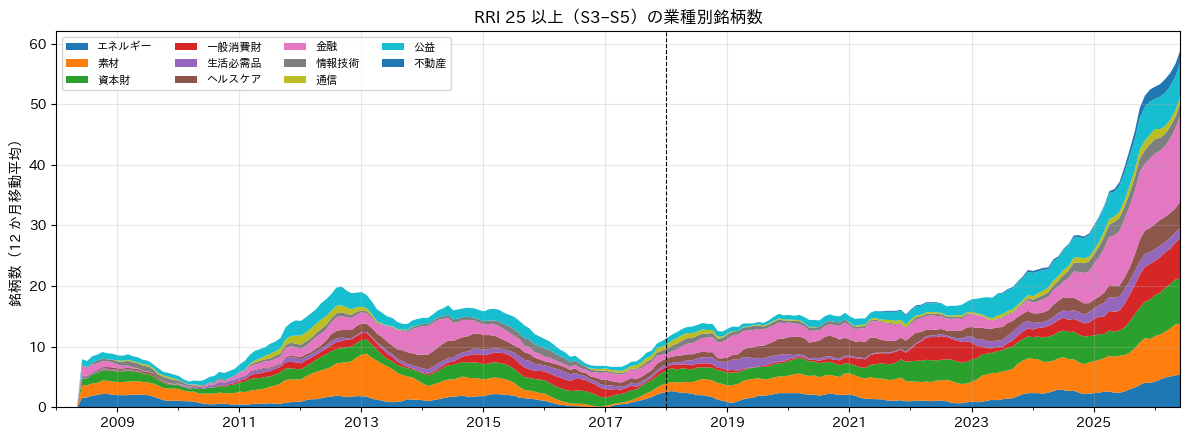

,前期 〜2017,後期 2018〜
S3 比率,0.096,0.099
S4 比率,0.200,0.222
S5 比率,0.704,0.679
時価総額シェア（対セグメント）,0.143,0.193


In [8]:
# 業種別の 25 以上 銘柄数の推移
sec_tail = sector.where(tail25)
by_sector = pd.DataFrame({SECTOR_NAMES.get(int(k), str(k)): (sec_tail == k).sum(axis=1) for k in sorted(SECTOR_NAMES)})
ax = by_sector.rolling(12, min_periods=6).mean().plot.area(figsize=(12, 4.5), linewidth=0)
ax.axvline(pd.Timestamp(SPLIT), color="k", linestyle="--", linewidth=0.8)
ax.set_ylabel("銘柄数（12 か月移動平均）")
ax.set_title("RRI 25 以上（S3–S5）の業種別銘柄数")
ax.legend(loc="upper left", ncol=4, fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# サイズ分位・時価総額シェア
size_rows = {}
for pname, per in list(PERIODS.items())[1:]:
    m = period_slice(tail25, per)
    sb = period_slice(size_bin, per).where(m).stack().value_counts(normalize=True).sort_index()
    w = period_slice(univ, per)
    seg_w = w.where(period_slice(scored, per))
    size_rows[pname] = {**{f"S{int(k)} 比率": v for k, v in sb.items()}, "時価総額シェア（対セグメント）": (w.where(m).sum(axis=1) / seg_w.sum(axis=1)).mean()}
display(pd.DataFrame(size_rows).round(3))

#### 業種中立の効果

25 以上の各銘柄について「同月・同業種（S3〜S5、スコアあり）の等ウェイトリターン」を差し引いた業種相対リターンを
等ウェイト平均し、業種で説明できない部分の劣後を期間別に見る。
併せて、前期の劣後にどの業種が寄与したかを分解する。

In [9]:
def sector_neutral(w: pd.DataFrame, member_ref: pd.DataFrame) -> tuple[pd.Series, pd.DataFrame]:
    """業種相対リターン Σ_i w_i (r_i − r_sector(i)) と、その業種別寄与を返す（日付は翌月）。"""
    contrib = {}
    for k, name in SECTOR_NAMES.items():
        mask = (sector == k).reindex(index=w.index, columns=w.columns).fillna(False)
        w_k = w.where(mask).fillna(0.0)
        part = portfolio_returns(w_k, rtn)                       # Σ_{i∈k} w_i r_i（正規化しない）
        r_k = group_return(member_ref & (sector == k))           # 業種 k の等ウェイトリターン
        share = pd.Series(w_k.sum(axis=1).to_numpy()[: len(part)], index=part.index)
        contrib[name] = part - share * r_k.reindex(part.index).fillna(0.0)
    contrib = pd.DataFrame(contrib)
    return contrib.sum(axis=1), contrib

w_tail = weight_portfolio(tail25.fillna(False))
tail_neutral, tail_contrib = sector_neutral(w_tail, scored)
display(spread_table({"25以上（業種中立: 参照 − テール）": -tail_neutral, "25以上（生: 参照 − テール）": spreads["水準 25以上"]}).round(3))

年率  年率リスク    R/R     勝率     月数
定義                   期間                                         
25以上（業種中立: 参照 − テール） 全期間       0.034  0.094  0.358  0.527  222.0
                     前期 〜2017  0.076  0.104  0.724  0.605  119.0
                     後期 2018〜 -0.015  0.079 -0.185  0.437  103.0
25以上（生: 参照 − テール）    全期間       0.062  0.109  0.571  0.554  222.0
                     前期 〜2017  0.139  0.118  1.178  0.630  119.0
                     後期 2018〜 -0.027  0.092 -0.289  0.466  103.0

In [10]:
# 前期・後期の劣後（業種相対）への業種別寄与（年率換算）
contrib = pd.DataFrame({pname: period_slice(tail_contrib, per).mean() * 12 for pname, per in list(PERIODS.items())[1:]})
contrib.loc["合計"] = contrib.sum()
display(contrib.round(4))

,前期 〜2017,後期 2018〜
エネルギー,-0.0182,-0.0021
素材,-0.0186,-0.0016
資本財,0.0116,-0.0002
一般消費財,-0.0055,0.0035
生活必需品,-0.0038,0.0028
ヘルスケア,-0.0085,0.0002
金融,-0.0075,0.0130
情報技術,-0.0180,0.0084
通信,0.0055,-0.0040
公益,-0.0129,-0.0054


### 4. IC の期間別推移

S3〜S5 で、翌月リターンに対する

- Spearman IC（$-\text{RRI}$）
- 25 以上ダミー（$-1$ = 25 以上）の Pearson IC
- 上位 10% ダミーの Pearson IC

を全期間・前期・後期で要約し、36 か月ローリング平均を描く。

mean    std   icir  t_stat  hit_rate      n
定義             期間                                                    
Spearman(−RRI) 全期間       0.012  0.114  0.108   1.610     0.532  222.0
               前期 〜2017  0.029  0.114  0.252   2.762     0.592  120.0
               後期 2018〜 -0.007  0.112 -0.062  -0.622     0.461  102.0
25以上ダミー        全期間       0.011  0.090  0.126   1.873     0.550  222.0
               前期 〜2017  0.028  0.084  0.329   3.607     0.625  120.0
               後期 2018〜 -0.008  0.093 -0.085  -0.859     0.461  102.0
上位10%ダミー       全期間       0.009  0.098  0.090   1.335     0.532  222.0
               前期 〜2017  0.018  0.102  0.176   1.933     0.583  120.0
               後期 2018〜 -0.002  0.094 -0.021  -0.211     0.471  102.0
非ゼロダミー         全期間       0.012  0.105  0.111   1.661     0.509  222.0
               前期 〜2017  0.020  0.112  0.183   2.008     0.517  120.0
               後期 2018〜  0.002  0.097  0.016   0.159     0.500  102.0

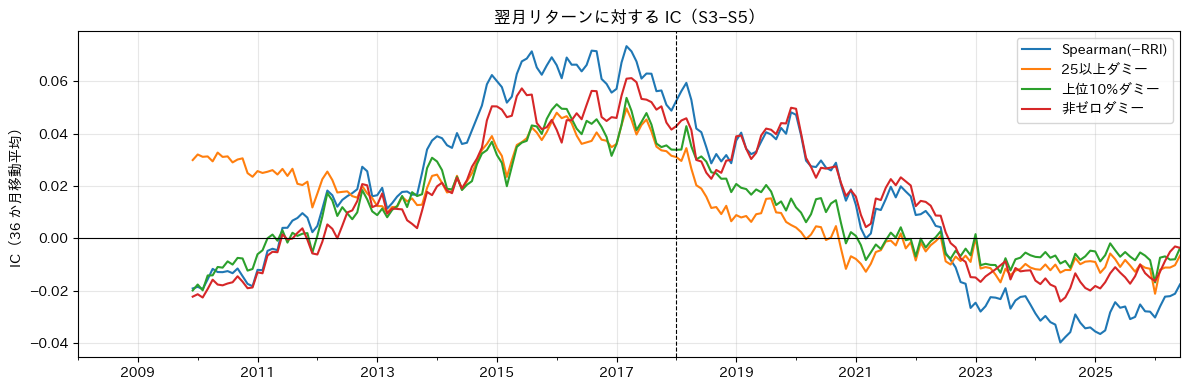

In [11]:
fwd1 = forward_returns(rtn, 1)
seg_univ = univ.where(seg)
ic_defs = {
    "Spearman(−RRI)": information_coefficient(-s_seg, fwd1, seg_univ, "spearman"),
    "25以上ダミー": information_coefficient(-tails["水準 25以上"].astype(float).where(scored), fwd1, seg_univ, "pearson"),
    "上位10%ダミー": information_coefficient(-tails["上位 10%"].astype(float).where(scored), fwd1, seg_univ, "pearson"),
    "非ゼロダミー": information_coefficient(-(s_seg > 0).astype(float).where(scored), fwd1, seg_univ, "pearson"),
}
ic_df = pd.DataFrame(ic_defs)
rows = {}
for name in ic_df.columns:
    for pname, per in PERIODS.items():
        summ = ic_summary(period_slice(ic_df[name], per))
        rows[(name, pname)] = summ[["mean", "std", "icir", "t_stat", "hit_rate", "n"]]
tbl = pd.DataFrame(rows).T
tbl.index.names = ["定義", "期間"]
display(tbl.round(3))

ax = ic_df.rolling(36, min_periods=24).mean().plot(figsize=(12, 4))
ax.axhline(0, color="k", linewidth=0.8)
ax.axvline(pd.Timestamp(SPLIT), color="k", linestyle="--", linewidth=0.8)
ax.set_ylabel("IC（36 か月移動平均）")
ax.set_title("翌月リターンに対する IC（S3–S5）")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 5. 所見

**テールの定義（参照 − テール、S3〜S5 等ウェイト）**

| 定義 | 前期 〜2017 年率 / R/R | 後期 2018〜 年率 / R/R |
| --- | --- | --- |
| 水準 25 以上 | +13.9% / 1.18 | −2.7% / −0.29 |
| 上位 5% | +8.7% / 0.68 | −2.7% / −0.19 |
| 上位 10% | +5.2% / 0.50 | −0.5% / −0.05 |
| 上位 15% | +3.8% / 0.45 | −1.6% / −0.23 |

- 順位でテールを定義しても後期の効果は戻らない。どの定義でも後期は年率ゼロ〜マイナス、勝率 46〜48%。
- 前期でも水準 25 以上が順位定義より強い。「25 以上」という水準そのものに情報があり、
  順位上位 x% にすると 25 未満の銘柄が混ざって効果が薄まる（前期の上位 10% は平均 15 銘柄で 25 以上の 11 銘柄より多い）。
- **消失は閾値のドリフト（カバレッジ拡張）では説明できない。**

**25 以上の構成変化**

- 業種は両期間ともエネルギー（対セグメント比 2.4〜2.7 倍）、公益（1.6 倍）、素材（1.2〜1.5 倍）に偏る。
  後期は金融の比率が 0.62 → 1.03 倍に上がり、素材がやや下がった以外は大きく変わらない。
- サイズは両期間とも S5 が約 70%、時価総額シェアは 14% → 19%。構成の変化は緩やかで、消失の主因とは考えにくい。

**業種中立の効果**

| 参照 − テール（25 以上） | 前期 | 後期 |
| --- | --- | --- |
| 生 | +13.9% / R/R 1.18 | −2.7% / −0.29 |
| 業種中立 | +7.6% / R/R 0.72 | −1.5% / −0.19 |

- 前期の劣後のおよそ半分は業種（エネルギー −1.8%、素材 −1.9%、情報技術 −1.8%、公益 −1.3%、年率寄与）で、
  残り半分（年率 7.6%）が業種内の銘柄選択によるもの。前期は業種中立でも R/R 0.72 と有意。
- 後期は業種中立でも効果は無い（金融 +1.3% が唯一目立つ寄与で、これはテールに入った金融株が
  むしろ業種内で堅調だったことを示す）。

**IC（S3〜S5、翌月リターン）**

| 定義 | 前期 mean / t 値 | 後期 mean / t 値 |
| --- | --- | --- |
| Spearman（−RRI） | 0.029 / 2.8 | −0.007 / −0.6 |
| 25 以上ダミー | 0.028 / 3.6 | −0.008 / −0.9 |
| 上位 10% ダミー | 0.018 / 1.9 | −0.002 / −0.2 |
| 非ゼロダミー | 0.020 / 2.0 | 0.002 / 0.2 |

- 前期は 25 以上ダミーの IC が最も安定（ICIR 0.33、勝率 63%）。後期はすべての定義で符号が消える。
  36 か月移動平均でも 2018 年前後を境に 0 近傍へ落ちている。

**まとめ**

1. 2008〜2017 年の「RRI 25 以上の劣後」は、業種ティルト（エネルギー・素材・公益）が半分、業種内の銘柄選択が半分で、
   当時は統計的に有意だった（業種中立 R/R 0.72、IC の t 値 3.6）。
2. 2018 年以降はテールの定義（水準 / 順位）、業種中立の有無、IC のいずれで見ても効果が消えている。
   閾値のドリフトや構成変化では説明できず、**市場のレジーム変化か、情報が織り込まれるようになった**と解釈するのが自然。
3. 現時点の判断: RRI は単独のリターン予測シグナルとしては採用できない。使うとすれば
   (a) リスク管理（レピュテーション事案の除外）としての位置づけで、リターン寄与は期待しない、
   (b) 他のシグナルとの組み合わせでテールリスクを削る補助的な用途、に限る。

**後続ステップの候補**

- リターンを `srtn`（BARRA 固有リターン）に替えて同じ分析を行い、前期の効果のうちファクター（業種・サイズ・
  バリュー等）で説明できない部分がどれだけあったかを確認する（`return_list` の `srtn` を使うだけで済む）。
- 水準ではなく**変化**（RRI の上昇、新規に 25 以上になったイベント）に情報が残っているかを確認する。
  レピュテーション事案の「発生直後」の反応はレジームに依存しにくい可能性がある。
- 25 以上を除外したポートフォリオ（ゼロ + 1–24）の税引後評価（回転率・税ドラッグ）を `alphaeval.tax` で出し、
  除外スクリーンとしてのコストを把握する。